In [140]:
import pandas as pd
import polars as pl
import time
import requests
from pymongo import MongoClient
from pprint import pprint
import psycopg
from pathlib import Path
import pandas as pd
from sqlalchemy import create_engine
import io
import matplotlib.pyplot as plt



In [141]:
sql = """
WITH notes AS (
  SELECT
    serialnumber,
    STRING_AGG(remarks, ' | ' ORDER BY note_id)      AS remarks_all,
    STRING_AGG(opm_remarks, ' | ' ORDER BY note_id)  AS opm_remarks_all
  FROM d_sale_notes
  GROUP BY serialnumber
)
SELECT
  f.sale_id,
  f.serialnumber,
  f.listyear,
  f.daterecorded,
  f.assessedvalue,
  f.saleamount,
  f.salesratio,

  p.address,
  p.propertytype,
  p.residentialtype,
  p.latitude,
  p.longitude,

  t.town,
  n.nonusecode,

  notes.remarks_all,
  notes.opm_remarks_all
FROM f_sales AS f
JOIN d_property AS p
  ON p.property_id = f.property_id
JOIN d_town AS t
  ON t.town_id = p.town_id
LEFT JOIN d_non_use_code AS n
  ON n.nonusecode_id = f.nonusecode_id
LEFT JOIN notes
  ON notes.serialnumber = f.serialnumber;
"""
conn = psycopg.connect("host=127.0.0.1 port=5433 dbname=realestate user=postgres sslmode=disable")
cur = conn.cursor()

In [142]:
import polars as pl

cur.execute(sql)
rows = cur.fetchall()
cols = [d[0] for d in cur.description]

df_ml = pl.DataFrame(rows, schema=cols)
print(df_ml.shape)
print(df_ml.head())

C:\Users\sebas\AppData\Local\Temp\ipykernel_29424\1936928366.py:7: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df_ml = pl.DataFrame(rows, schema=cols)


(1141722, 16)
shape: (5, 16)
┌─────────┬────────────┬──────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ sale_id ┆ serialnumb ┆ listyear ┆ daterecord ┆ … ┆ town      ┆ nonusecod ┆ remarks_a ┆ opm_remar │
│ ---     ┆ er         ┆ ---      ┆ ed         ┆   ┆ ---       ┆ e         ┆ ll        ┆ ks_all    │
│ i64     ┆ ---        ┆ i64      ┆ ---        ┆   ┆ str       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ str        ┆          ┆ date       ┆   ┆           ┆ str       ┆ str       ┆ str       │
╞═════════╪════════════╪══════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 11      ┆ 40056      ┆ 2004     ┆ 2004-11-29 ┆ … ┆ RIDGEFIEL ┆ null      ┆ UNKNOWN   ┆ UNKNOWN   │
│         ┆            ┆          ┆            ┆   ┆ D         ┆           ┆           ┆           │
│ 27      ┆ 230181     ┆ 2023     ┆ 2024-02-20 ┆ … ┆ VERNON    ┆ null      ┆ UNKNOWN | ┆ RENOVATED │
│         ┆            ┆          ┆            ┆   ┆          

In [144]:
numeric_types = {
	pl.Int8, pl.Int16, pl.Int32, pl.Int64,
	pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
	pl.Float32, pl.Float64}

num_cols  = [c for c, t in zip(df_ml.columns, df_ml.dtypes) if t in numeric_types]
cat_cols  = [c for c, t in zip(df_ml.columns, df_ml.dtypes) if t in (pl.Utf8, pl.Categorical)]
date_cosl = [c for c, t in zip(df_ml.columns, df_ml.dtypes) if t in (pl.Date, pl.Datetime)]


In [145]:
print("Num cols:", num_cols)
print("Cat cols:", cat_cols)
print("Date cols:", date_cols)

Num cols: ['sale_id', 'listyear', 'assessedvalue', 'saleamount', 'salesratio', 'latitude', 'longitude']
Cat cols: ['serialnumber', 'address', 'propertytype', 'residentialtype', 'town', 'nonusecode', 'remarks_all', 'opm_remarks_all']
Date cols: ['daterecorded']


In [146]:
df_ml.select(pl.all().null_count())

sale_id,serialnumber,listyear,daterecorded,assessedvalue,saleamount,salesratio,address,propertytype,residentialtype,latitude,longitude,town,nonusecode,remarks_all,opm_remarks_all
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,2,0,0,1,0,0,0,796538,796538,0,816915,0,0


In [147]:
df_ml = df_ml.with_columns(pl.col("nonusecode").fill_null("UKNOWN"))
df_ml = df_ml.with_columns(pl.col("latitude").fill_null(0))
df_ml = df_ml.with_columns(pl.col("longitude").fill_null(0))

In [148]:
df_ml.select(pl.all().null_count())

sale_id,serialnumber,listyear,daterecorded,assessedvalue,saleamount,salesratio,address,propertytype,residentialtype,latitude,longitude,town,nonusecode,remarks_all,opm_remarks_all
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0


## Numeric

In [167]:
num_cols = [c for c in num_cols if c != "sale_id"]
df_ml.select(pl.col(num_cols)).describe()

statistic,listyear,assessedvalue,saleamount,salesratio,latitude,longitude
str,f64,f64,f64,f64,f64,f64
"""count""",1.141722e6,1.141722e6,1.141722e6,1.141721e6,1.141722e6,1.141722e6
"""null_count""",0.0,0.0,0.0,1.0,0.0,0.0
"""mean""",2011.673398,283327.51902,410450.975448,9.279262,12.546429,-22.032851
"""std""",7.018679,1.6561e6,5.0490e6,1766.534436,19.059448,33.470349
"""min""",2001.0,0.0,0.0,0.0,0.0,-121.23091
"""25%""",2005.0,89910.0,146100.0,0.4737,0.0,-72.49784
"""50%""",2012.0,141980.0,237500.0,0.604758,0.0,0.0
"""75%""",2018.0,230060.0,383750.0,0.764857,41.218713,0.0
"""max""",2023.0,8.8151e8,5.0000e9,1.22642e6,44.93459,0.0


In [168]:
df_ml.select(pl.col(num_cols)).describe()

statistic,listyear,assessedvalue,saleamount,salesratio,latitude,longitude
str,f64,f64,f64,f64,f64,f64
"""count""",1.141722e6,1.141722e6,1.141722e6,1.141721e6,1.141722e6,1.141722e6
"""null_count""",0.0,0.0,0.0,1.0,0.0,0.0
"""mean""",2011.673398,283327.51902,410450.975448,9.279262,12.546429,-22.032851
"""std""",7.018679,1.6561e6,5.0490e6,1766.534436,19.059448,33.470349
"""min""",2001.0,0.0,0.0,0.0,0.0,-121.23091
"""25%""",2005.0,89910.0,146100.0,0.4737,0.0,-72.49784
"""50%""",2012.0,141980.0,237500.0,0.604758,0.0,0.0
"""75%""",2018.0,230060.0,383750.0,0.764857,41.218713,0.0
"""max""",2023.0,8.8151e8,5.0000e9,1.22642e6,44.93459,0.0


In [154]:
def hist_box_log(df, col):
    x = df[col].drop_nulls().to_numpy()
    x = np.log1p(x)  # log(1+x) evita problemas con ceros

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,5),
                                   gridspec_kw={"height_ratios":[3,1]},
                                   sharex=True)

    ax1.hist(x, bins="auto", color="#2a9d8f")
    ax1.set_title(f"{col} (log1p transform)")
    ax2.boxplot(x, vert=False)

    plt.tight_layout()
    plt.show()

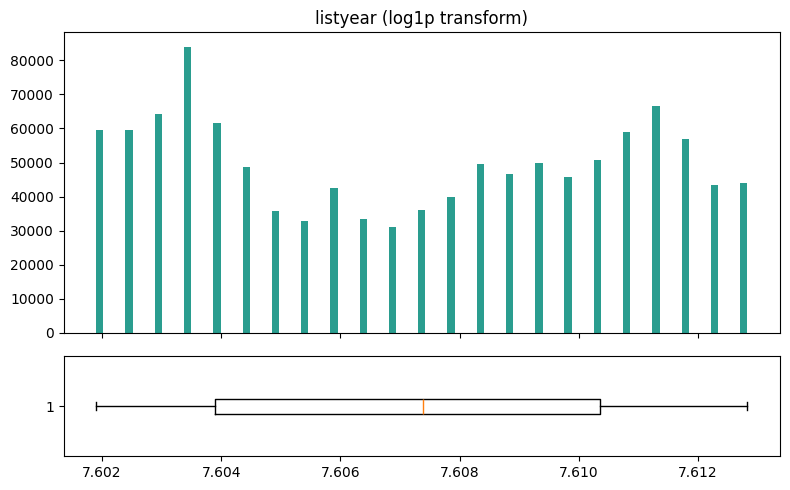

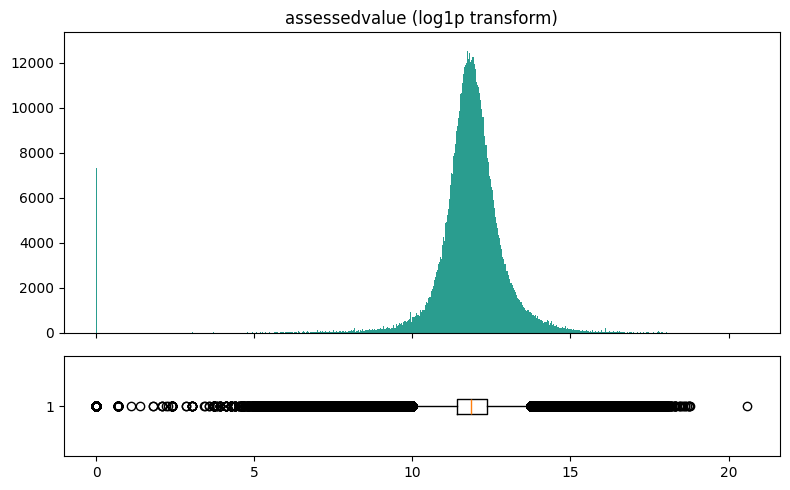

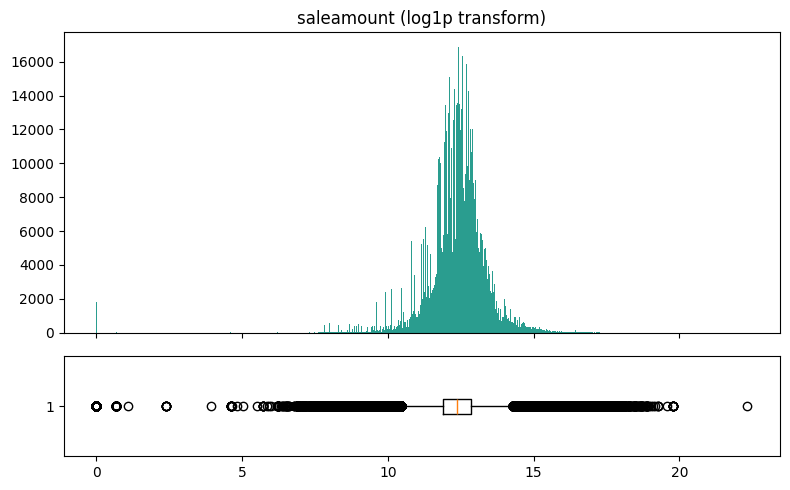

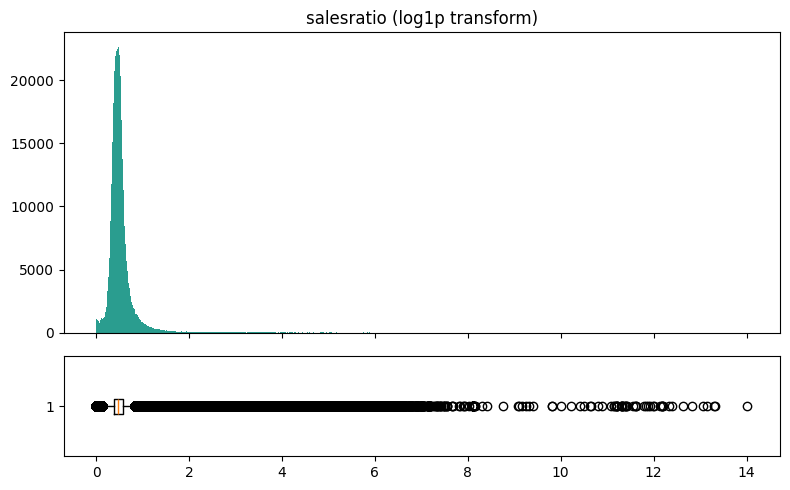

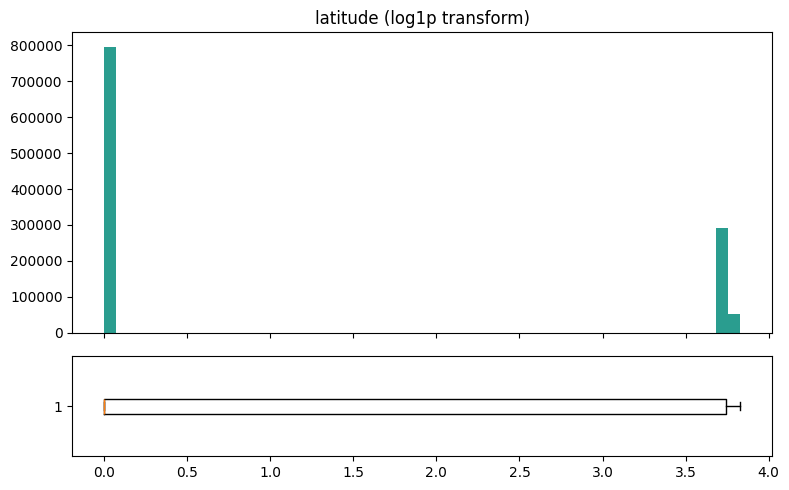

C:\Users\sebas\AppData\Local\Temp\ipykernel_29424\1442515663.py:3: RuntimeWarning: invalid value encountered in log1p
  x = np.log1p(x)  # log(1+x) evita problemas con ceros


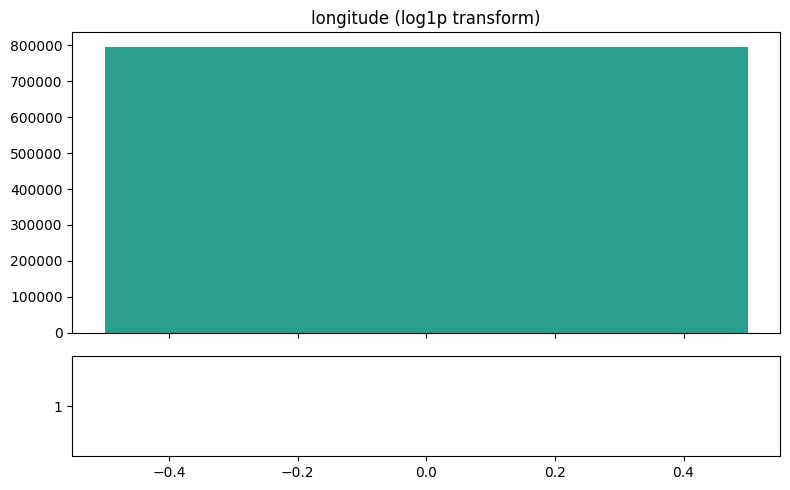

In [155]:
for col in num_cols:
    hist_box_log(df_ml, col)

## Categóricas

In [152]:
cat_cols

['serialnumber',
 'address',
 'propertytype',
 'residentialtype',
 'town',
 'nonusecode',
 'remarks_all',
 'opm_remarks_all']

In [160]:
import polars as pl

df_ml = df_ml.with_columns([
    pl.col("propertytype").cast(pl.Categorical),
    pl.col("residentialtype").cast(pl.Categorical),
    pl.col("town").cast(pl.Categorical),
    pl.col("nonusecode").cast(pl.Categorical),
])

In [ ]:
def top_counts(df, col, n=20):
    return (
        df.group_by(col)
          .len()
          .sort("len", descending=True)
          .head(n)   ) 

top_counts(df_ml, "town", 30)
#top_counts(df_ml, "propertytype", 20)
#top_counts(df_ml, "residentialtype", 20)


town,len
cat,u32
"""BRIDGEPORT""",39680
"""STAMFORD""",38178
"""WATERBURY""",34186
"""NORWALK""",27995
"""NEW HAVEN""",24786
…,…
"""CANAAN""",547
"""HARTLAND""",538
"""SCOTLAND""",485
